In [66]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import splrep, splev

In [7]:
scaler_train = joblib.load(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\models\Model 2\scaler_train_AR23-014.scale")

In [15]:
scaler_train.scale_

array([1.78571429e+00, 1.35135135e-01, 1.33333333e-01, 9.24285747e+01,
       2.90697674e-01, 2.83529408e+01, 8.82272706e+01, 3.42700480e-02,
       2.00909114e-04, 2.96735905e-02, 1.19047619e-02, 4.40528634e-01,
       1.11607143e-01, 1.81818182e-01, 3.33222259e-02, 1.80831826e-01])

In [18]:
list1 = [5,6,7,8,9,9]
list2 = [5] + list1
list2

[5, 5, 6, 7, 8, 9, 9]

In [21]:
0 - np.array([5]).item()

-5

In [22]:
max(np.array([5,6,7,8,9,10]))

10

In [34]:
test = np.zeros([14, 4])

In [31]:
test = np.zeros([15,2])
test[:,0] = 0
test[:,1] = 1
test

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [49]:
df = pd.read_csv(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\AR23-014-Model-Data.csv")
grouped = df.groupby("Batch", group_keys=False)
df_group = grouped.apply(lambda group: group.interpolate(method = 'linear', limit_direction='backward',limit=2))

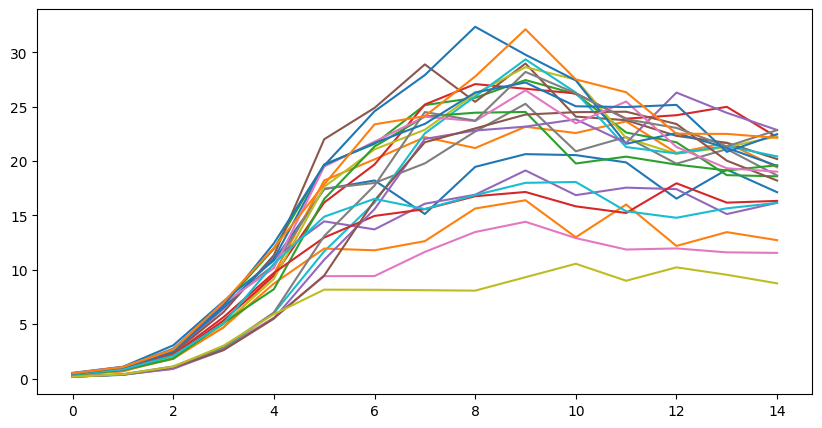

In [53]:
plt.figure(figsize=(10,5))
grouped_2 = df_group.groupby("Batch", group_keys=False)
for _, group in grouped_2:
    x = group["Day"]
    y = group["VCC"]
    plt.plot(x,y)

In [56]:
grouped_3 = df_group.groupby("Batch", group_keys=False)
smooth_data = []
splines = set(["VCC","IGG","Ammonium"])
for _, group in grouped_3:
    for col in splines:
        x = group["Day"].values
        y = group[col].values
        spl = splrep(x,y)
        smooth_y = splev(x, spl)
        group[col] = smooth_y

    smooth_data.append(group)
smooth_data = pd.concat(smooth_data)

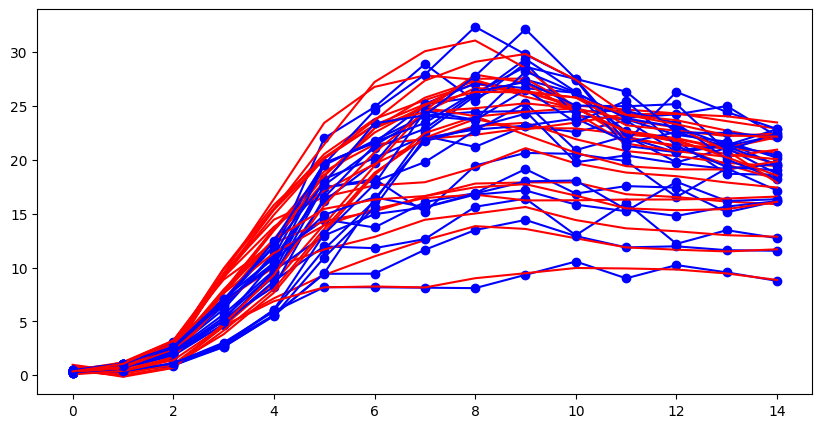

In [99]:
plt.figure(figsize=(10,5))
grouped_4 = smooth_data.groupby("Batch", group_keys=False)
for _, group in grouped_4:
    x = group["Day"]
    y = group["VCC"]
    yhat = savgol_filter(y, 6, 2)
    plt.plot(x,y, "bo-")
    plt.plot(x,yhat, "r-")

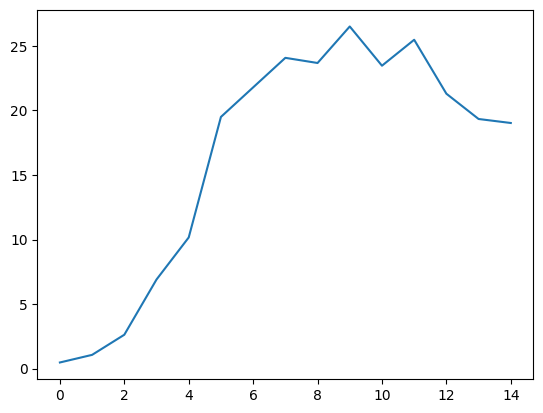

In [61]:
x = grouped_4.get_group("AR23-014-017")["Day"]
y = grouped_4.get_group("AR23-014-017")["VCC"]
plt.plot(x,y)

In [62]:
smooth_data_2 = []
for col in splines:
    x = grouped_4.get_group("AR23-014-017")["Day"].values
    y = grouped_4.get_group("AR23-014-017")["VCC"].values
    spl = splrep(x,y)
    smooth_y = splev(x, spl)
    grouped_4.get_group("AR23-014-017")["VCC"] = smooth_y
    smooth_data_2.append(group)
smooth_data_2 = pd.concat(smooth_data_2)

C:\Users\zah48132\AppData\Local\Temp\ipykernel_27404\3568976060.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_4.get_group("AR23-014-017")["VCC"] = smooth_y


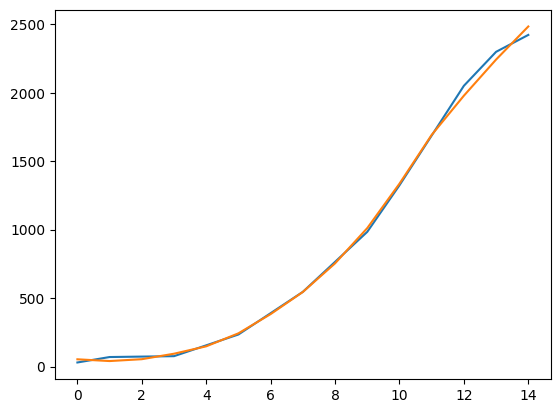

In [132]:
grouped_5 = smooth_data_2.groupby("Batch", group_keys=False)
x = grouped_4.get_group("AR23-014-004")["Day"]
y = grouped_4.get_group("AR23-014-020")["IGG"]
yhat = savgol_filter(y, 7, 2)
plt.plot(x,y)
plt.plot(x,yhat)

In [141]:
header = ["VCC","Lactate","IGG"]
df_a = pd.read_csv(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\models\Model 2\data\B_Matrix.csv", header=None)
print(df_a.to_markdown(index=False))

|         0 |         1 |           2 |           3 |
|----------:|----------:|------------:|------------:|
| -0.1863   |  0.495116 | -0.0304475  | -0.0425543  |
|  0.393914 | -0.395079 |  0.0403181  |  0.385505   |
|  0.124161 |  0.110922 |  0.00110679 | -0.00859193 |


In [137]:
df_a.to_markdown()

'|    |          0 |          1 |            2 |\n|---:|-----------:|-----------:|-------------:|\n|  0 | -0.191333  |  0.348639  | -0.0091029   |\n|  1 | -0.0142399 | -0.575035  |  0.0229528   |\n|  2 |  0.0397055 | -0.0431091 |  0.000589102 |'